In [1]:
%%writefile app/image_utils.py
"""
Day 6 - 이미지 업로드 안전장치 + 전처리
"""
from fastapi import UploadFile, HTTPException
from PIL import Image
import io

# 허용 설정
ALLOWED_TYPES = {"image/png", "image/jpeg", "image/jpg"}
MAX_FILE_SIZE = 5 * 1024 * 1024  # 5MB                     # *your code* — 최대 파일 크기


async def validate_and_read_image(
    file: UploadFile,
    max_size: int = MAX_FILE_SIZE,
    target_size: tuple = (28, 28),
) -> Image.Image:
    """
    업로드된 파일을 검증하고, PIL 이미지로 반환합니다.

    검증 순서:
      1. 파일 타입 검증 → 허용된 형식(PNG, JPEG)만 통과
      2. 파일 크기 검증 → 5MB 이하만 통과
      3. 이미지 디코딩 검증 → 실제로 열 수 있는 이미지만 통과
      4. 리사이징 + 그레이스케일 변환 → 모델 입력 크기에 맞춤
    """

    # ─── 1. 파일 타입 검증 ─────────────────────────
    # content_type은 클라이언트가 보낸 MIME 타입입니다.
    # .exe를 .png로 위장해도 content_type이 다르므로 차단됩니다.
    if file.content_type not in ALLOWED_TYPES:               # *your code* — 타입 체크
        raise HTTPException(
            status_code=400,
            detail=f"지원하지 않는 파일 형식입니다: {file.content_type}. "
                   f"허용 형식: {ALLOWED_TYPES}",
        )

    # ─── 2. 파일 크기 검증 ─────────────────────────
    # 파일 전체를 읽어서 크기를 확인합니다.
    # 이 시점에서 파일 내용이 메모리에 올라옵니다.
    contents = await file.read()
    if len(contents) > max_size:                             # *your code* — 크기 체크
        raise HTTPException(
            status_code=400,
            detail=f"파일 크기가 {max_size // (1024*1024)}MB를 초과합니다. "
                   f"현재: {len(contents) / (1024*1024):.1f}MB",
        )

    # ─── 3. 이미지 디코딩 검증 ─────────────────────
    # content_type이 image/png여도 파일 내용이 실제로 이미지가 아닐 수 있습니다.
    # PIL로 열어보면서 확인합니다.
    try:
        image = Image.open(io.BytesIO(contents))
    except Exception:
        raise HTTPException(
            status_code=400,
            detail="이미지를 읽을 수 없습니다. 파일이 손상되었을 수 있습니다.",
        )

    # ─── 4. 리사이징 + 그레이스케일 변환 ──────────────
    # 어떤 크기의 이미지가 들어와도 모델 입력에 맞게 변환합니다.
    image = image.convert("L").resize(target_size)           # *your code* — 그레이스케일 + 리사이즈

    return image

Writing app/image_utils.py


In [2]:
from PIL import Image
import io

# 테스트 이미지 생성 (28x28 그레이스케일)
test_img = Image.new("L", (100, 100), color=128)   # 100x100 회색 이미지
buffer = io.BytesIO()
test_img.save(buffer, format="PNG")
test_bytes = buffer.getvalue()

print(f"테스트 이미지 크기: {len(test_bytes)} bytes")
print(f"테스트 이미지 해상도: {test_img.size}")

테스트 이미지 크기: 120 bytes
테스트 이미지 해상도: (100, 100)


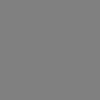

In [3]:
test_img.show()

In [4]:
%%writefile app/image_api.py
"""
Day 6 - 이미지 분류 API (인증 + 파일 업로드 + MNIST 모델)
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

import torch
from fastapi import FastAPI, UploadFile, File, Depends, HTTPException
from torchvision import transforms

from app.model_utils import load_model, predict, CLASS_NAMES
from app.auth import verify_api_key
from app.image_utils import validate_and_read_image
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("image_api")

app = FastAPI(
    title="Image Classification API",
    description="이미지를 업로드하면 숫자(0~9)를 분류하는 API (인증 필요)",
    version="1.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="image")

# ===== 모델 로드 =====
MODEL_PATH = "models/mnist_state_dict.pth"
model = None

# 전처리 파이프라인 (PIL → Tensor)
img_transform = transforms.Compose([               # *your code* — transforms.Compose 구성
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


@app.on_event("startup")
async def startup():
    global model
    logger.info("MNIST 모델 로드 중...")
    model = load_model(MODEL_PATH)
    logger.info("모델 로드 완료")


def run_inference(tensor: torch.Tensor) -> dict:
    if model is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return predict(model, tensor)


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {"status": "healthy" if model else "loading"}


@app.post("/predict/image", tags=["Inference"])
async def predict_image(
    file: UploadFile = File(..., description="분류할 이미지 (PNG, JPEG)"),
    user: str = Depends(verify_api_key),                     # *your code* — 인증 적용
):
    """
    이미지를 업로드하면 숫자(0~9)를 분류합니다.
    X-API-Key 헤더에 유효한 API Key가 필요합니다.
    """
    logger.info(f"추론 요청 — 사용자: {user}, 파일: {file.filename}")

    # 1. 파일 검증 + 이미지 로드 (28x28 그레이스케일로 변환)
    image = await validate_and_read_image(file, target_size=(28, 28))  # *your code* — 안전장치 적용

    # 2. 텐서 변환
    tensor = img_transform(image).unsqueeze(0)   # (1, 1, 28, 28)

    # 3. 비동기 추론
    try:
        loop = asyncio.get_event_loop()
        result = await loop.run_in_executor(executor, run_inference, tensor)
    except Exception as e:
        logger.error(f"추론 실패: {e}")
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    logger.info(f"추론 완료 — 결과: {result['predicted_class']}, 확신도: {result['confidence']:.2f}")

    return {
        "success": True,
        "predicted_class": result["predicted_class"],
        "confidence": round(result["confidence"], 4),
        "user": user,
    }

Writing app/image_api.py


In [21]:
%%writefile app/auth.py
"""
Day 6 - API Key 인증
"""
from fastapi import HTTPException, Header

# API Key 설정
# 실무에서는 환경 변수나 시크릿 매니저에서 로드합니다.
# 여기서는 학습 목적으로 하드코딩합니다.
VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:  # *your code* — Header에서 키 추출
    """
    API Key를 검증합니다.
    FastAPI의 Depends()로 엔드포인트에 주입합니다.

    Returns:
        인증된 사용자 이름
    Raises:
        HTTPException: 키가 없거나 유효하지 않을 때
    """
    if x_api_key is None:
        raise HTTPException(
            status_code=401,                       # *your code* — Unauthorized
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )

    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )

    return VALID_API_KEYS[x_api_key]  # 사용자 이름 반환

Overwriting app/auth.py


In [7]:
import requests

# API Key 없이 요청
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    # headers 없음 → 인증 실패
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

상태 코드: 401
응답: {'detail': 'X-API-Key header is missing'}


In [8]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    headers={"X-API-Key": "wrong-key"},                      # *your code* — 잘못된 키
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

상태 코드: 401
응답: {'detail': 'Invalid API key'}


In [19]:
from torchvision import datasets
from PIL import Image
import io

# MNIST 테스트 이미지 가져오기
test_dataset = datasets.MNIST(root="data", train=False, download=True)
test_image, test_label = test_dataset[0]   # 첫 번째 테스트 이미지

# PIL 이미지 → bytes 변환
buf = io.BytesIO()
test_image.save(buf, format="PNG")
image_bytes = buf.getvalue()

print(f"테스트 이미지 정답: {test_label}")

# API 호출
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("digit.png", image_bytes, "image/png")},
    headers={"X-API-Key": "test-key-001"},                   # *your code* — 올바른 키
)

print(f"상태 코드: {response.status_code}")   # 200
result = response.json()
print(f"예측 결과: {result}")

테스트 이미지 정답: 7
상태 코드: 200
예측 결과: {'success': True, 'predicted_class': '7', 'confidence': 1.0, 'user': {'user_id': 11, 'name': 'test-user', 'role': 'admin'}}


In [11]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.txt", b"this is not an image", "text/plain")},
    headers={"X-API-Key": "test-key-001"},
)

print(f"상태 코드: {response.status_code}")   # 400
print(f"응답: {response.json()}")

상태 코드: 401
응답: {'detail': 'Invalid API key'}


In [20]:
import requests
from torchvision import datasets
from PIL import Image
import io

test_dataset = datasets.MNIST(root="data", train=False, download=True)

print("=== 연속 추론 테스트 (5장) ===\n")

for i in range(5):
    img, label = test_dataset[i]

    buf = io.BytesIO()
    img.save(buf, format="PNG")

    resp = requests.post(
        "http://localhost:8000/predict/image",
        files={"file": (f"digit_{i}.png", buf.getvalue(), "image/png")},
        headers={"X-API-Key": "test-key-001"},
    )

    r = resp.json()
    predicted = r.get("predicted_class", "?")
    confidence = r.get("confidence", 0)
    match = "✅" if str(label) == str(predicted) else "❌"

    print(f"  이미지 {i}: 정답={label}, 예측={predicted}, 확신도={confidence:.4f} {match}")

=== 연속 추론 테스트 (5장) ===

  이미지 0: 정답=7, 예측=7, 확신도=1.0000 ✅
  이미지 1: 정답=2, 예측=2, 확신도=1.0000 ✅
  이미지 2: 정답=1, 예측=1, 확신도=1.0000 ✅
  이미지 3: 정답=0, 예측=0, 확신도=1.0000 ✅
  이미지 4: 정답=4, 예측=4, 확신도=1.0000 ✅
